# Pandas Practice 2

![IRIS, https://github.com/simonava5/fishers-iris-data](./images/iris.png)

After the notebook with a lot of new input, let's start applying it totally by yourselves. 
For this purpose we will use one of the most standard real-life datasets: Its called Iris Dataset, and is all about the plant iris. Let's learn a little bit more about the dataset by looking at it. 

## Learning Objectives





By the end of this notebook, you will feel more comfortable with your newly acquired knowledge, as you will see that you can

- load data from csv files into DataFrames
- access data stored in DataFrames
- use the general functions of a DataFrame to answer questions about the data
- create insightful plots using the pandas function `.plot()`
- explain what conclusions you draw from these visualizations.


In [1]:
# import pandas
import pandas as pd

In [2]:
# load the data
df = pd.read_csv('data/iris.csv')

Let us first have a look at the head of the table, maybe also on the last 10 rows...

In [5]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.tail(10)

,sepal_length,sepal_width,petal_length,petal_width,species
140,6.7,3.1,5.6,2.4,Iris-virginica
141,6.9,3.1,5.1,2.3,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica
143,6.8,3.2,5.9,2.3,Iris-virginica
144,6.7,3.3,5.7,2.5,Iris-virginica
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


How many irises are in the data set?

In [ ]:
df.info() # 150 irises are in the dataset.

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


How many different species are there?

In [ ]:
df['species'].unique() # 3 different spieces are there

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

Calculate the mean, median, mode for petal length

In [17]:
print("mean:", df['petal_length'].mean(), " median:", df['petal_length'].median(), " mode:", df['petal_length'].mode()[0])

mean: 3.758666666666666  median: 4.35  mode: 1.5


What can you conclude about the distribution for petal length?

The distribution of petal length is not symmetric and appears multimodal, likely due to the presence of different iris species with different petal lengths.

What is the smallest and largest value for petal length?

In [19]:
df["petal_length"].min()

np.float64(1.0)

In [20]:
df["petal_length"].max()

np.float64(6.9)

Calculate the variance and standard deviation for petal length

In [22]:
df["petal_length"].var()

np.float64(3.113179418344519)

In [23]:
df["petal_length"].std()

np.float64(1.7644204199522626)

Calculate the basic descriptive statistics for all columns of the iris data set with a single command.

In [24]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


What is the overall average for sepal length?

In [25]:
df["sepal_length"].mean()

np.float64(5.843333333333334)

Use the DataFrame grouping function to determine the count by species.

In [28]:
df.groupby("species").size()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

Use the DataFrame grouping function to determine the average length and width of sepals and pedals by species.

In [29]:
df.groupby("species")[[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]].mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


Add the sum of the sepal width and length as a new column to your DataFrame.

In [30]:
df["sepal_total"] = df["sepal_length"] + df["sepal_width"]

Visualize petal length with a histogram

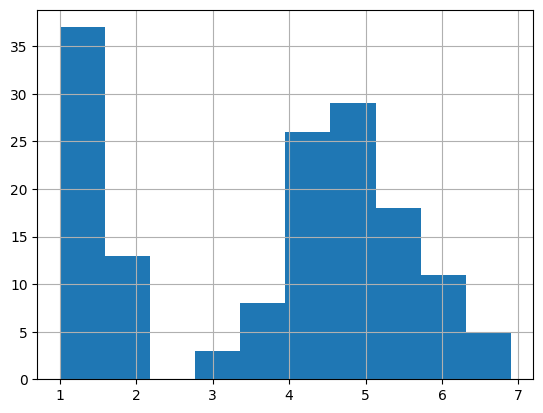

In [31]:
import matplotlib.pyplot as plt

df["petal_length"].hist()
plt.show()

Describe the distribution

The distribution of petal length is not uniform. 
It appears to have multiple peaks because the dataset contains different iris species with distinct petal lengths.

Which is more informative: the summary statistics or visualizations?

Visualizations are often more informative because they reveal patterns and distributions that summary statistics may hide.

Visualize petal length and width with a "scatter_matrix"

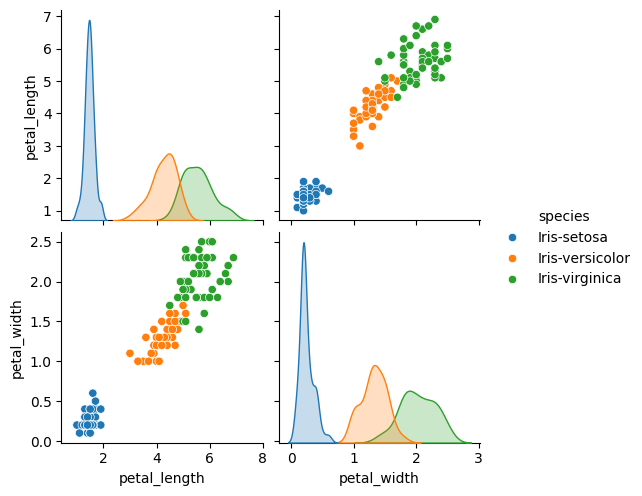

In [32]:
import seaborn as sns

sns.pairplot(df, vars=["petal_length", "petal_width"], hue="species")

Create a new column with a rough estimate of petal area by multiplying petal length and width together.

In [33]:
df["petal_area"] = df["petal_length"] * df["petal_width"]

Create a new DataFrame with petal areas greater than $1cm^2$.

In [34]:
df_large_petals = df[df["petal_area"] > 1]

In [35]:
df_large_petals.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_total,petal_area
50,7.0,3.2,4.7,1.4,Iris-versicolor,10.2,6.58
51,6.4,3.2,4.5,1.5,Iris-versicolor,9.6,6.75
52,6.9,3.1,4.9,1.5,Iris-versicolor,10.0,7.35
53,5.5,2.3,4.0,1.3,Iris-versicolor,7.8,5.20
54,6.5,2.8,4.6,1.5,Iris-versicolor,9.3,6.90


Create 3 new DataFrames, one for each species. Use the entire dataset.

In [39]:
setosa_df = df[df["species"] == "Iris-setosa"]
versicolor_df = df[df["species"] == "Iris-versicolor"]
virginica_df = df[df["species"] == "Iris-virginica"]

In [40]:
setosa_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_total,petal_area
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6,0.28
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9,0.28
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9,0.26
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7,0.30
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6,0.28
